# E2 Latent Steering — Results
Set `DECODER` and `METHOD` then run all cells.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Edit these ────────────────────────────────────────────────────────────────
DECODER     = "whisper"          # "whisper" | "whisfusion"
METHOD      = "position"              # "dtw" | "position"
ROOT        = Path("/vol/gpudata/tsv22-fyp/accent-robust-asr")
RESULTS_DIR = Path(f"{ROOT}/results/e2_steering")
# ─────────────────────────────────────────────────────────────────────────────

sns.set_style("whitegrid")
print(f"decoder={DECODER}  method={METHOD}")
print(f"results dir: {RESULTS_DIR}")

csv_path = RESULTS_DIR / f"{DECODER}_{METHOD}_steering.csv"
# assert csv_path.exists(), f"Not found: {csv_path}"

df = pd.read_csv(csv_path)
df["alpha"] = pd.to_numeric(df["alpha"])
print(f"Loaded {len(df)} rows — {df['L1'].nunique()} L1s, {df['alpha'].nunique()} alpha values")
print(df.groupby("alpha")["wer"].agg(["mean","std"]).round(4))

decoder=whisper  method=position
results dir: /vol/gpudata/tsv22-fyp/accent-robust-asr/results/e2_steering
Loaded 3546 rows — 6 L1s, 6 alpha values
         mean     std
alpha                
0.00   0.2061  0.2258
0.25   0.4989  3.5426
0.50   2.2230  8.1427
0.75   0.1135  1.5061
0.90   0.0451  0.1007
1.00   0.0405  0.1021


In [2]:
def _stats(sub):
    s = sub.groupby("alpha")["wer"].agg(
        mean="mean",
        sem=lambda x: x.std(ddof=1) / len(x)**0.5
    ).reset_index().sort_values("alpha")
    return s

def _plot_pair(ax_w, ax_d, sub, title):
    stats    = _stats(sub)
    alphas   = stats["alpha"].values
    wers     = stats["mean"].values
    sems     = stats["sem"].values
    baseline = stats.loc[stats["alpha"] == 0.0, "mean"].values[0]
    deltas   = wers - baseline
    best_i   = int(np.argmin(wers))

    # WER — blue with error bars, best point highlighted
    ax_w.errorbar(alphas, wers, yerr=sems, fmt="o-", lw=2, ms=6,
                  color="steelblue", ecolor="steelblue", elinewidth=1.2,
                  capsize=3, zorder=2)
    ax_w.plot(alphas[best_i], wers[best_i], "o", ms=11,
              color="lightsteelblue", mec="steelblue", mew=2.5, zorder=3,
              label=f"Best \u03b1={alphas[best_i]}  {wers[best_i]:.3f}")
    ax_w.axhline(baseline, color="dimgray", ls="--", lw=1.5,
                 label=f"L2 baseline  {baseline:.3f}")
    ax_w.set_title(title, fontweight="bold")
    ax_w.set_xlabel("\u03b1"); ax_w.set_ylabel("WER")
    ax_w.legend(fontsize=8); ax_w.grid(True, alpha=0.3)

    # \u0394WER — green with error bars, best point highlighted
    ax_d.errorbar(alphas, deltas, yerr=sems, fmt="o-", lw=2, ms=6,
                  color="#27ae60", ecolor="#27ae60", elinewidth=1.2,
                  capsize=3, zorder=2)
    ax_d.plot(alphas[best_i], deltas[best_i], "o", ms=11,
              color="#a9dfbf", mec="#1a7a45", mew=2.5, zorder=3)
    ax_d.axhline(0, color="dimgray", ls="--", lw=1.5)
    ax_d.set_title(f"{title} (\u0394WER)", fontweight="bold")
    ax_d.set_xlabel("\u03b1"); ax_d.set_ylabel("\u0394WER")
    ax_d.grid(True, alpha=0.3)

print("\u2713 Plot helpers defined")

✓ Plot helpers defined


✓ whisper_position_overall.png


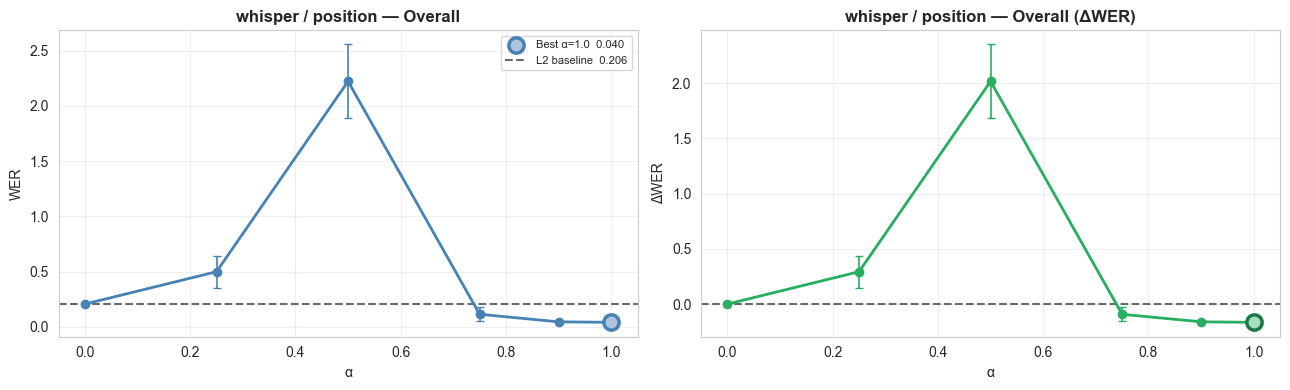

In [3]:
fig, (ax_w, ax_d) = plt.subplots(1, 2, figsize=(13, 4))
_plot_pair(ax_w, ax_d, df, f"{DECODER} / {METHOD} — Overall")
plt.tight_layout()
save = RESULTS_DIR / f"{DECODER}_{METHOD}_overall.png"
plt.savefig(save, dpi=150, bbox_inches="tight"); print(f"\u2713 {save.name}")
plt.show()

✓ whisper_position_fixed_per_l1.png


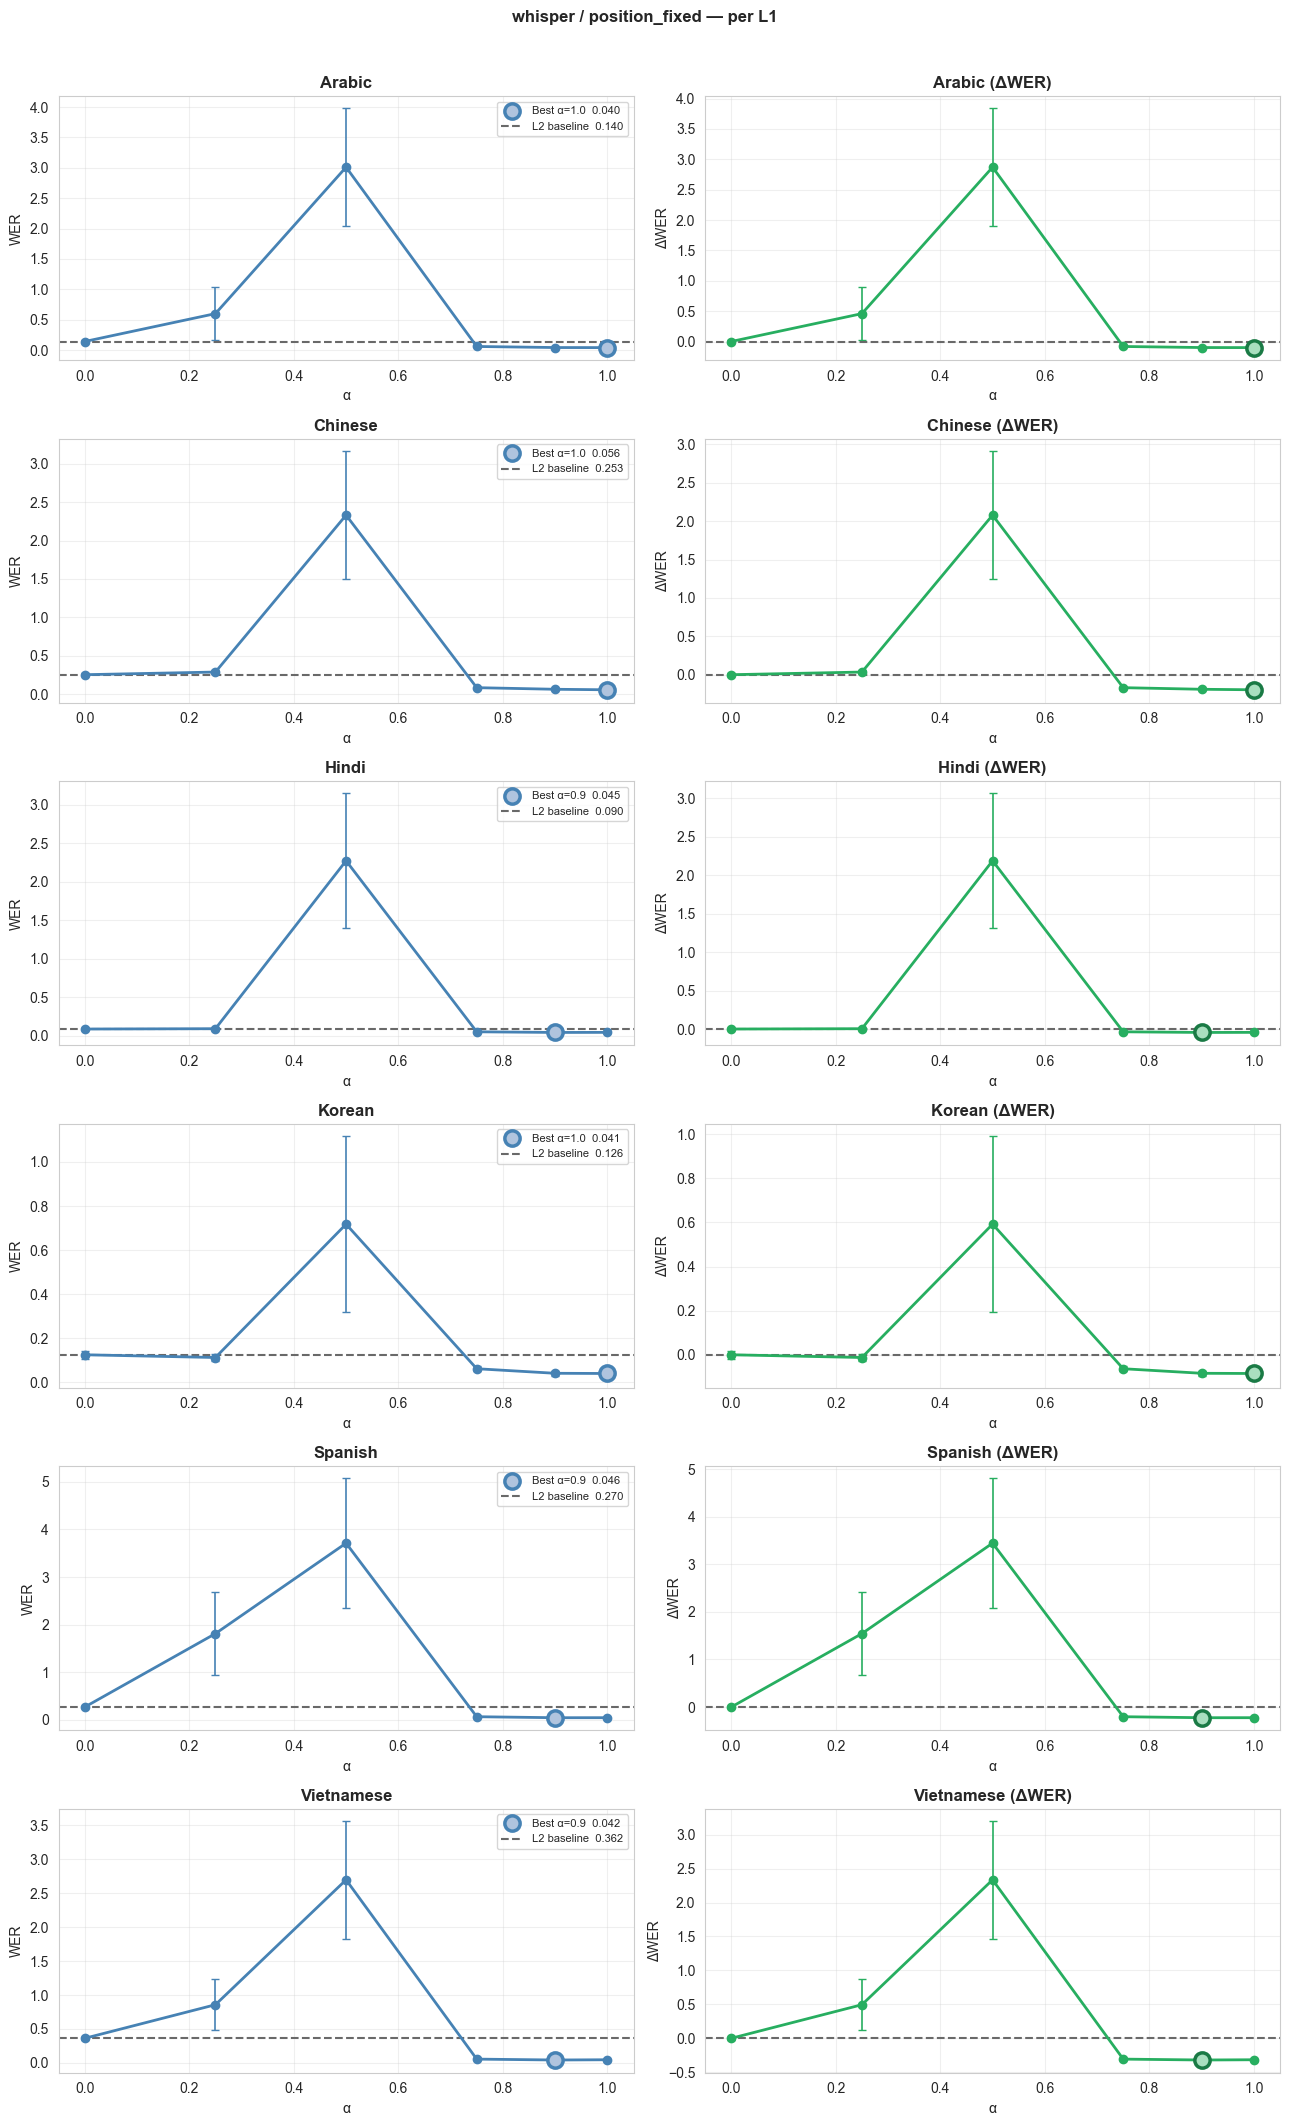

In [8]:
l1s = sorted(df["L1"].unique())
fig, axes = plt.subplots(len(l1s), 2, figsize=(13, 3.5 * len(l1s)))
for i, l1 in enumerate(l1s):
    _plot_pair(axes[i, 0], axes[i, 1], df[df["L1"] == l1], l1)
fig.suptitle(f"{DECODER} / {METHOD} — per L1", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
save = RESULTS_DIR / f"{DECODER}_{METHOD}_per_l1.png"
plt.savefig(save, dpi=150, bbox_inches="tight"); print(f"\u2713 {save.name}")
plt.show()

alpha,0.00,0.25,0.50,0.75,0.90,1.00
config,,,,,,
whisper_position,0.2061,0.4989,2.2230,0.1135,0.0451,0.0405
whisper_full_dtw,0.2112,0.1488,0.4585,0.0557,0.0515,0.0487
whisper_dtw_interpolate,0.2061,0.2537,0.3294,0.0472,0.0399,0.0405
whisper_position_fixed,0.2059,0.6093,2.4383,0.0635,0.0466,0.0459
whisper_dtw_english,0.2061,0.1271,0.1108,0.0440,0.0382,0.0405
whisper_dtw_l2,0.2061,0.1318,0.0712,0.0502,0.0466,0.0489


saved comparison_whisper_per_method.png


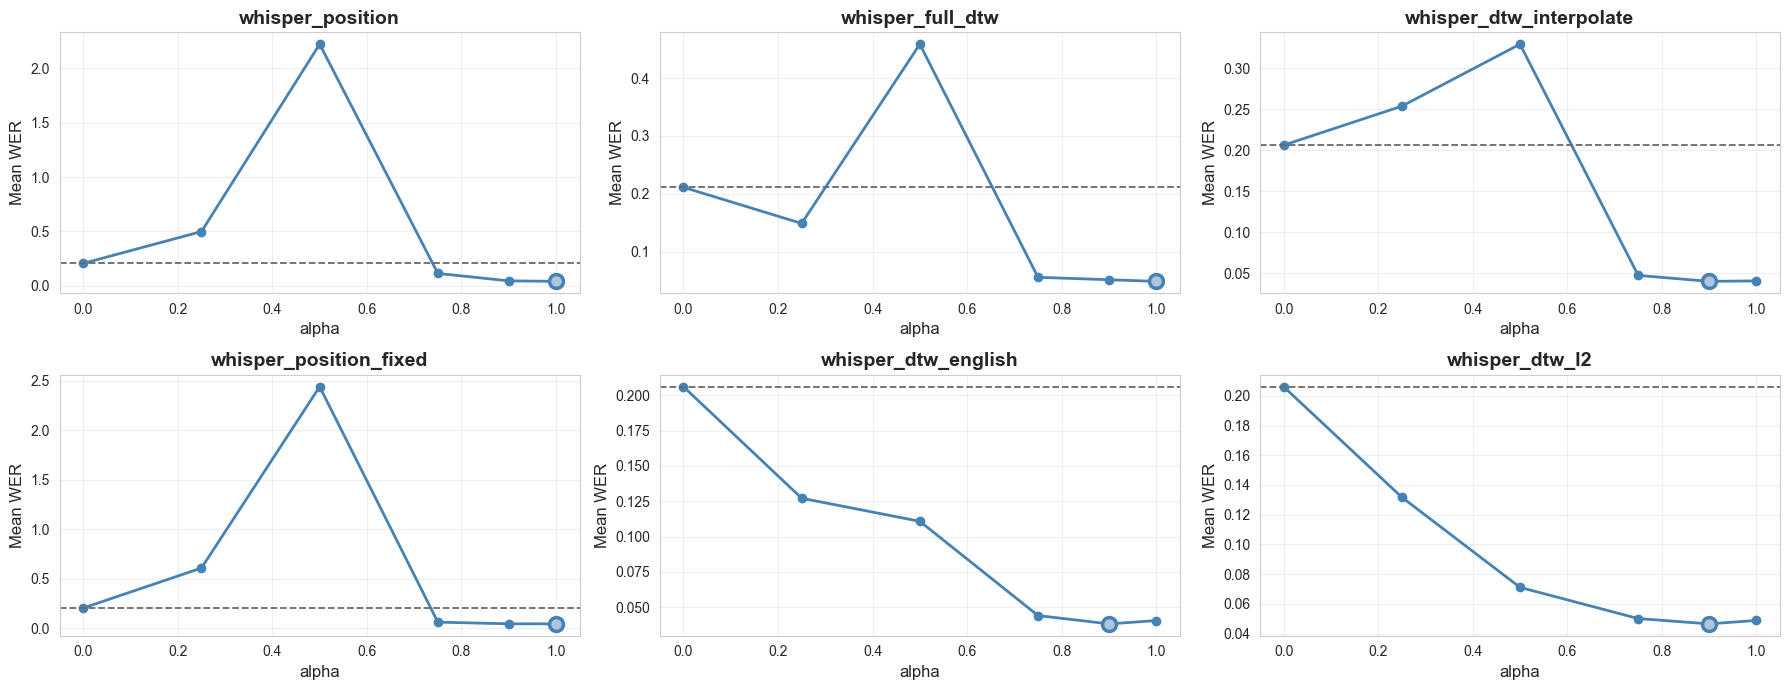

In [9]:
# -- Mean WER per alpha: comparison table + one plot per method ----------
COMPARE_DECODER = 'whisper'   # 'whisper' | 'whisfusion' | None (show all)

# Order controls subplot layout: first 3 = top row, last 2 = bottom row
CONFIGS = [
    'whisper_position',
    'whisper_full_dtw',
    'whisper_dtw_interpolate',
    'whisper_position_fixed',
    'whisper_dtw_english',
    'whisper_dtw_l2',
    'whisfusion_position',
    'whisfusion_full_dtw',
    'whisfusion_dtw_interpolate',
    'whisfusion_dtw_english',
    'whisfusion_dtw_l2',
]

active = [c for c in CONFIGS if (COMPARE_DECODER is None or c.startswith(COMPARE_DECODER))
          and (RESULTS_DIR / f'{c}_steering.csv').exists()]

dfs = {}
for cfg in active:
    d = pd.read_csv(RESULTS_DIR / f'{cfg}_steering.csv')
    d['alpha'] = pd.to_numeric(d['alpha'])
    dfs[cfg] = d

# -- Comparison table: one row per method, one column per alpha --------------
table = pd.DataFrame(
    {cfg: d.groupby('alpha')['wer'].mean().round(4) for cfg, d in dfs.items()}
).T
table.columns.name = 'alpha'
table.index.name = 'config'
display(table)

# -- 3-column grid: top row = 3, bottom row = 2 ------------------------------
n = len(dfs)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.5 * nrows), squeeze=False)

for ax in axes.flat[n:]:
    ax.set_visible(False)

for ax, (cfg, d) in zip(axes.flat, dfs.items()):
    stats    = d.groupby('alpha')['wer'].mean().sort_index()
    baseline = stats.loc[0.0]
    best_i   = int(stats.values.argmin())
    alphas   = stats.index.values
    wers     = stats.values

    ax.plot(alphas, wers, 'o-', lw=2, ms=6, color='steelblue')
    ax.plot(alphas[best_i], wers[best_i], 'o', ms=10,
            color='lightsteelblue', mec='steelblue', mew=2.5,
            label=f'best alpha={alphas[best_i]}  WER={wers[best_i]:.3f}')
    ax.axhline(baseline, color='dimgray', ls='--', lw=1.3)
    ax.set_title(cfg, fontweight='bold', fontsize=14)
    ax.set_xlabel('alpha', fontsize=12); ax.set_ylabel('Mean WER', fontsize=12)
    ax.grid(True, alpha=0.3)

title_tag = COMPARE_DECODER or 'all'
# fig.suptitle(f'Mean WER vs alpha — {title_tag}', fontweight='bold', y=1.01)
plt.tight_layout()
save = RESULTS_DIR / f'comparison_{title_tag}_per_method.png'
plt.savefig(save, dpi=150, bbox_inches='tight')
print(f'saved {save.name}')
plt.show()


In [10]:
# -- All-methods cosine similarity analysis -----------------------------------
# Computes cos_sim(steered_output, z_nat) for every active config and plots
# WER + cos_sim vs alpha in a grid.  DTW paths are computed once per utterance
# and reused across all DTW configs.  Uses `active` and `dfs` from the
# comparison cell above.

import os, json
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from dtaidistance import dtw_ndim

MAPPING_CACHE = Path(f'{ROOT}/src/analysis/cache/utterance_mapping.json')
TEST_DATA_DIR = Path(os.environ.get('TEST_DATA_DIR', '/vol/gpudata/tsv22-dev_test/data/processed/test'))
ALPHA_VALUES  = [0.0, 0.25, 0.5, 0.75, 0.9, 1.0]

with open(MAPPING_CACHE) as f:
    mapping = json.load(f)

# ── helpers ───────────────────────────────────────────────────────────────────
def _load_state(rel_path):
    pt = torch.load(TEST_DATA_DIR / rel_path, map_location='cpu', weights_only=False)
    hs = pt['hidden_states']
    return hs.to(torch.float32).numpy() if isinstance(hs, torch.Tensor) else np.array(hs, dtype=np.float32)

def _extend_sil(sil, need):
    if len(sil) == 0:
        return np.zeros((need, sil.shape[-1]), dtype=np.float32)
    if len(sil) >= need:
        return sil[:need]
    return np.vstack([sil, np.tile(sil[-1:], (need - len(sil), 1))])

def pad_to_1500(steered, l2_full, l2_end, eng_full, eng_end, alpha, tail):
    if alpha == 0.0:
        return l2_full[:1500].astype(np.float32)
    N = len(steered)
    if N >= 1500:
        return steered[:1500].astype(np.float32)
    need = 1500 - N
    if tail == 'english':
        padding = _extend_sil(eng_full[eng_end:], need)
    elif tail == 'interpolate':
        padding = ((1 - alpha) * _extend_sil(l2_full[l2_end:], need)
                   + alpha    * _extend_sil(eng_full[eng_end:], need)).astype(np.float32)
    else:  # l2
        padding = _extend_sil(l2_full[l2_end:], need)
    return np.vstack([steered, padding]).astype(np.float32)

def cos_sim_speech(a, b, end):
    a_s = a[:end].astype(np.float32)
    b_s = b[:end].astype(np.float32)
    num   = (a_s * b_s).sum(axis=1)
    denom = (np.linalg.norm(a_s, axis=1) * np.linalg.norm(b_s, axis=1)) + 1e-8
    return float((num / denom).mean())

# ── method/tail parser ────────────────────────────────────────────────────────
_SUFFIX_MAP = {
    'position':       ('position', None),
    'dtw_interpolate':('dtw', 'interpolate'),
    'dtw_l2':         ('dtw', 'l2'),
    'dtw_english':    ('dtw', 'english'),
}

def _method_tail(cfg):
    suffix = cfg.split('_', 1)[1] if '_' in cfg else cfg
    return _SUFFIX_MAP.get(suffix, (None, None))

# ── resolve active configs ─────────────────────────────────────────────────────
active_methods = {cfg: _method_tail(cfg) for cfg in active if _method_tail(cfg)[0] is not None}
skipped = [cfg for cfg in active if _method_tail(cfg)[0] is None]
if skipped:
    print(f'Skipping (unknown method): {skipped}')
print(f'Running cos_sim for: {list(active_methods)}')

# Use steering CSVs already loaded into `dfs` from the comparison cell
all_dfs = {cfg: dfs[cfg] for cfg in active_methods if cfg in dfs}

# Precompute (prompt_id, L1) membership sets for fast lookup
prompt_l1_sets = {
    cfg: set(zip(d['prompt_id'], d['L1']))
    for cfg, d in all_dfs.items()
}
all_prompts = {p for pairs in prompt_l1_sets.values() for p, _ in pairs}

any_dtw = any(m == 'dtw' for m, _ in active_methods.values())

# ── main loop: one pass over utterances, all configs ─────────────────────────
rows_per_cfg = {cfg: [] for cfg in active_methods}

for prompt_id, l1d in tqdm(mapping.items(), desc='Utterances'):
    if prompt_id not in all_prompts:
        continue
    eng_info = l1d.get('English')
    if not eng_info or not eng_info.get('speech_end_frame'):
        continue
    eng_end = eng_info['speech_end_frame']
    try:
        eng_full  = _load_state(eng_info['path'])
        eng_state = eng_full[:eng_end]
    except Exception:
        continue

    for l1, info in l1d.items():
        if l1 == 'English':
            continue
        l2_end = info.get('speech_end_frame')
        if not l2_end:
            continue
        key = (prompt_id, l1)
        if not any(key in s for s in prompt_l1_sets.values()):
            continue
        try:
            l2_full  = _load_state(info['path'])
            l2_state = l2_full[:l2_end]
        except Exception:
            continue

        # Compute DTW path once; reused by all DTW configs
        if any_dtw:
            path_arr = np.array(dtw_ndim.warping_path(eng_state, l2_state))
            i_norm   = path_arr[:, 0] / max(len(eng_state) - 1, 1)
            j_norm   = path_arr[:, 1] / max(len(l2_state)  - 1, 1)

        for cfg, (method, tail) in active_methods.items():
            if key not in prompt_l1_sets[cfg]:
                continue
            for alpha in ALPHA_VALUES:
                if method == 'position':
                    padded = ((1 - alpha) * l2_full[:1500]
                              + alpha     * eng_full[:1500]).astype(np.float32)
                else:
                    N     = max(1, round((1 - alpha) * len(l2_state) + alpha * len(eng_state)))
                    t_k   = (1 - alpha) * j_norm + alpha * i_norm
                    out_t = np.linspace(0.0, 1.0, N)
                    idx_r = np.clip(np.searchsorted(t_k, out_t), 0, len(t_k) - 1)
                    idx_l = np.clip(idx_r - 1, 0, len(t_k) - 1)
                    k_idx = np.where(np.abs(t_k[idx_l] - out_t) <= np.abs(t_k[idx_r] - out_t),
                                     idx_l, idx_r)
                    steered = ((1 - alpha) * l2_state[path_arr[k_idx, 1]]
                               + alpha     * eng_state[path_arr[k_idx, 0]]).astype(np.float32)
                    padded  = pad_to_1500(steered, l2_full, l2_end, eng_full, eng_end, alpha, tail)

                rows_per_cfg[cfg].append({
                    'prompt_id': prompt_id, 'L1': l1, 'speaker': info['speaker'],
                    'alpha': alpha,
                    'cos_sim': cos_sim_speech(padded, eng_full, eng_end),
                })

# ── merge cos_sim with steering CSVs ─────────────────────────────────────────
merged_all = {}
for cfg, rows in rows_per_cfg.items():
    cos_df = pd.DataFrame(rows)
    merged = all_dfs[cfg].merge(cos_df, on=['prompt_id', 'L1', 'speaker', 'alpha'])
    merged_all[cfg] = merged
    print(f'{cfg}: {len(merged)} rows')

# ── grid plot: WER + cos_sim vs alpha ────────────────────────────────────────
n     = len(merged_all)
ncols = 2
nrows =2
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), squeeze=False)
for ax in axes.flat[n:]:
    ax.set_visible(False)

for ax, (cfg, merged) in zip(axes.flat, merged_all.items()):
    stats = merged.groupby('alpha').agg(
        wer_mean=('wer',     'mean'),
        cos_mean=('cos_sim', 'mean'),
        wer_sem =('wer',     lambda x: x.std(ddof=1) / len(x)**0.5),
        cos_sem =('cos_sim', lambda x: x.std(ddof=1) / len(x)**0.5),
    ).reset_index().sort_values('alpha')

    ax2 = ax.twinx()
    ax.errorbar(stats['alpha'], stats['wer_mean'], yerr=stats['wer_sem'],
                fmt='o-', color='steelblue', lw=2, ms=5, capsize=3, label='WER')
    ax2.errorbar(stats['alpha'], stats['cos_mean'], yerr=stats['cos_sem'],
                 fmt='s--', color='tomato', lw=2, ms=5, capsize=3, label='cos_sim')
    ax.set_title(cfg, fontweight='bold', fontsize=9)
    ax.set_xlabel('alpha (0=L2, 1=English)')
    ax.set_ylabel('WER', color='steelblue')
    ax2.set_ylabel('cos_sim (vs eng)', color='tomato')
    ax.tick_params(axis='y', colors='steelblue')
    ax2.tick_params(axis='y', colors='tomato')
    ax.grid(True, alpha=0.3)

title_tag = COMPARE_DECODER or 'all'
fig.suptitle(f'WER & cos_sim vs alpha — {title_tag}', fontweight='bold', y=1.01)
plt.tight_layout()
save = RESULTS_DIR / f'cossim_all_{title_tag}.png'
plt.savefig(save, dpi=150, bbox_inches='tight')
print(f'saved {save.name}')
plt.show()


Skipping (unknown method): ['whisper_full_dtw', 'whisper_position_fixed']
Running cos_sim for: ['whisper_position', 'whisper_dtw_interpolate', 'whisper_dtw_english', 'whisper_dtw_l2']


Utterances:  33%|███▎      | 373/1132 [00:29<01:00, 12.54it/s]


KeyboardInterrupt: 